# Dimensionless Ambipolar Transport Equation: Mathematical Derivation

## Objective

The objective of this notebook is to derive the dimensionless form of the one-dimensional transient ambipolar transport equation. The dimensionless formulation reduces the governing equation to a form containing only a few dimensionless parameters, making it suitable for numerical implementation, validation, and subsequent coupling with the dimensionless heat equation.

---

# 1. Dimensional Governing Equation

The one-dimensional transient ambipolar transport equation without thermal coupling is

$$
\frac{\partial p}{\partial t}
=
D\frac{\partial^2p}{\partial x^2}
-
v\frac{\partial p}{\partial x}
$$

where

| Symbol | Description | Unit |
|---------|-------------|------|
| $p$ | Carrier concentration | m$^{-3}$ |
| $x$ | Spatial coordinate | m |
| $t$ | Time | s |
| $D$ | Diffusion coefficient | m$^2$/s |
| $v$ | Drift velocity | m/s |

---

# 2. Choice of Characteristic Scales

To maintain consistency with the heat equation, the same characteristic length and time scales are used.

## Characteristic Length

Let

$$
L
$$

be the characteristic device length.

Define the dimensionless coordinate

$$
X=\frac{x}{L}.
$$

Thus,

$$
0\le X\le1.
$$

---

## Characteristic Time

The thermal diffusion time obtained from the heat equation is

$$
t_c=\frac{L^2}{\alpha}
$$

where

$$
\alpha=\frac{k}{\rho C_p}
$$

is the thermal diffusivity.

The dimensionless time is therefore

$$
\tau=\frac{t}{t_c}
=
\frac{\alpha t}{L^2}.
$$

Using the same time scale allows both governing equations to share the same dimensionless time variable, simplifying the coupled formulation.

---

## Characteristic Carrier Concentration

Let

$$
p_0
$$

be a characteristic carrier concentration.

Define the dimensionless carrier concentration as

$$
P=\frac{p}{p_0}.
$$

Hence,

$$
p=p_0P.
$$

---

# 3. Transformation of Derivatives

## Time Derivative

Applying the chain rule,

$$
\frac{\partial p}{\partial t}
=
p_0
\frac{\alpha}{L^2}
\frac{\partial P}{\partial\tau}.
$$

---

## First Spatial Derivative

Since

$$
x=LX,
$$

the first derivative becomes

$$
\frac{\partial p}{\partial x}
=
\frac{p_0}{L}
\frac{\partial P}{\partial X}.
$$

---

## Second Spatial Derivative

Differentiating once more,

$$
\frac{\partial^2p}{\partial x^2}
=
\frac{p_0}{L^2}
\frac{\partial^2P}{\partial X^2}.
$$

---

# 4. Substitution into the Governing Equation

Substituting the transformed derivatives into the dimensional equation,

$$
p_0
\frac{\alpha}{L^2}
\frac{\partial P}{\partial\tau}
=
D
\frac{p_0}{L^2}
\frac{\partial^2P}{\partial X^2}
-
v
\frac{p_0}{L}
\frac{\partial P}{\partial X}.
$$

Dividing by

$$
\frac{p_0\alpha}{L^2},
$$

gives

$$
\frac{\partial P}{\partial\tau}
=
\frac{D}{\alpha}
\frac{\partial^2P}{\partial X^2}
-
\frac{vL}{\alpha}
\frac{\partial P}{\partial X}.
$$

---

# 5. Dimensionless Parameters

Define the dimensionless diffusion ratio

$$
\boxed{
Le=\frac{D}{\alpha}
}
$$

where

- $D$ is the carrier diffusion coefficient,
- $\alpha$ is the thermal diffusivity.

The parameter $Le$ represents the ratio of carrier diffusion to thermal diffusion.

---

Define the Péclet number

$$
\boxed{
Pe=\frac{vL}{\alpha}
}
$$

which represents the relative strength of drift transport compared to thermal diffusion.

---

# 6. Dimensionless Governing Equation

The final dimensionless ambipolar transport equation becomes

$$
\boxed{
\frac{\partial P}{\partial\tau}
=
Le
\frac{\partial^2P}{\partial X^2}
-
Pe
\frac{\partial P}{\partial X}
}
$$

---

# 7. Boundary Conditions

The dimensionless boundary conditions are

$$
P(0,\tau)=0,
$$

$$
P(1,\tau)=1.
$$

---

# 8. Initial Condition

The initial carrier distribution is chosen as

$$
P(X,0)=\sin(\pi X).
$$

This smooth profile satisfies the boundary values and provides a suitable transient initial condition.

---

# 9. Steady-State Equation

At steady state,

$$
\frac{\partial P}{\partial\tau}=0.
$$

Hence,

$$
Le
\frac{d^2P}{dX^2}
-
Pe
\frac{dP}{dX}
=
0.
$$

Introducing

$$
m=\frac{Pe}{Le},
$$

the equation becomes

$$
\frac{d^2P}{dX^2}
-
m
\frac{dP}{dX}
=
0.
$$

---

## General Solution

The characteristic equation is

$$
r(r-m)=0.
$$

Therefore,

$$
P(X)
=
C_1
+
C_2e^{mX}.
$$

Applying

$$
P(0)=0,
$$

and

$$
P(1)=1,
$$

gives

$$
C_2=\frac{1}{e^m-1},
$$

and

$$
C_1=-\frac{1}{e^m-1}.
$$

Thus,

$$
\boxed{
P(X)
=
\frac{e^{mX}-1}{e^m-1},
}
$$

where

$$
m=\frac{Pe}{Le}.
$$

---

# 10. Summary of Dimensionless Parameters

| Symbol | Definition | Physical Meaning |
|---------|------------|------------------|
| $X$ | $\dfrac{x}{L}$ | Dimensionless position |
| $\tau$ | $\dfrac{\alpha t}{L^2}$ | Dimensionless time |
| $P$ | $\dfrac{p}{p_0}$ | Dimensionless carrier concentration |
| $Le$ | $\dfrac{D}{\alpha}$ | Diffusion ratio |
| $Pe$ | $\dfrac{vL}{\alpha}$ | Péclet number |

---

# Conclusion

The transient ambipolar transport equation has been transformed into a dimensionless form using the same characteristic scales as the heat equation. The resulting equation depends only on the dimensionless parameters $Le$ and $Pe$, which quantify the relative effects of diffusion and drift transport. This formulation provides a consistent framework for numerical implementation and facilitates subsequent one-way coupling with the dimensionless heat equation.

Steady state reached after 511 steps

Maximum Error : 2.824084e-03
L2 Error      : 1.962656e-03


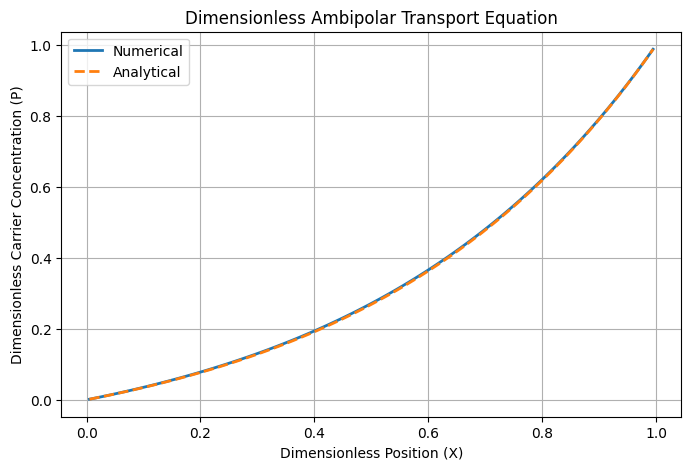

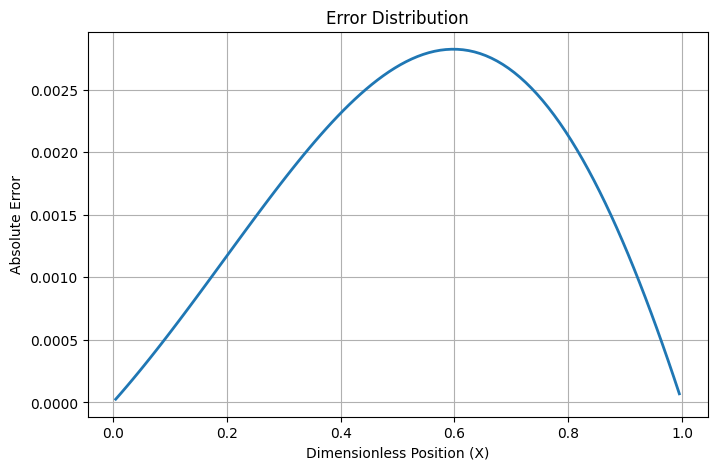


VALIDATION SUMMARY
Diffusion Ratio (Le) : 1.0
Peclet Number (Pe)   : 2.0
Number of Cells      : 100
Time Step            : 0.001
Steady-State Steps   : 511

Maximum Error : 2.824084e-03
L2 Error      : 1.962656e-03

Result : PASS
The numerical solution agrees well with the analytical solution.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

# Dimensionless Ambipolar Transport Equation :-∂P/∂τ = Le ∂²P/∂X² − Pe ∂P/∂X

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

# Dimensionless Parameters
Le = 1.0          # Diffusion ratio
Pe = 2.0          # Peclet number

dt = 1e-3
max_steps = 10000
tolerance = 1e-8

P = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0]),
    name="Carrier Concentration"
)

# Boundary Conditions
P.constrain(0.0, mesh.facesLeft)
P.constrain(1.0, mesh.facesRight)

# Governing Equation
eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=Le)
    -
    PowerLawConvectionTerm(coeff=(Pe,))
)

for step in range(max_steps):

    old = P.value.copy()

    eq.solve(var=P, dt=dt)

    max_change = np.max(np.abs(P.value - old))

    if max_change < tolerance:
        print(f"Steady state reached after {step + 1} steps")
        break

# Analytical Solution

x = np.array(mesh.cellCenters[0])

m = Pe / Le

P_exact = (np.exp(m * x) - 1.0) / (np.exp(m) - 1.0)

error = np.abs(P.value - P_exact)

max_error = error.max()
l2_error = np.sqrt(np.mean(error**2))

print(f"\nMaximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

# Numerical vs Analytical Solution

plt.figure(figsize=(8,5))

plt.plot(
    x,
    P.value,
    linewidth=2,
    label="Numerical"
)

plt.plot(
    x,
    P_exact,
    "--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Dimensionless Carrier Concentration (P)")
plt.title("Dimensionless Ambipolar Transport Equation")

plt.grid(True)
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Absolute Error")
plt.title("Error Distribution")

plt.grid(True)

plt.show()

print("\n==============================")
print("VALIDATION SUMMARY")
print("==============================")

print(f"Diffusion Ratio (Le) : {Le}")
print(f"Peclet Number (Pe)   : {Pe}")
print(f"Number of Cells      : {nx}")
print(f"Time Step            : {dt}")
print(f"Steady-State Steps   : {step + 1}")

print(f"\nMaximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

if max_error < 1e-2:
    print("\nResult : PASS")
    print("The numerical solution agrees well with the analytical solution.")
else:
    print("\nResult : CHECK")
    print("Further refinement may be required.")